<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/TabMRealMLP_EDGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:

# CELL 1 — CONFIG

DO_MOUNT_DRIVE = True
DO_DOWNLOAD    = True  # Set True only for first time download

DATASET_ID     = "mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot"
DRIVE_CACHE    = "/content/drive/MyDrive/kagglehub_cache"
TARGET_ALIAS   = "/content/drive/MyDrive/datasets/edge_iiotset_dataset"

DRIVE_DATASET  = "/content/drive/MyDrive/datasets/edge_iiotset_dataset"
DRIVE_OUT_DIR  = "/content/drive/MyDrive/edge_iiotset_ml_outputs"

# Edge-IIoTset label column
LABEL_COL = "Attack_type"
ML_FILE   = "ML-EdgeIIoT-dataset.csv"

RANDOM_SEED    = 42
TEST_SIZE      = 0.2
VAL_SIZE       = 0.1
BATCH_SIZE     = 512
N_EPOCHS_TABM  = 256
EARLY_STOPPING = 20

In [17]:
# CELL 2 — INSTALL


!pip install -q pytabkit
!pip install -q tabm
!pip install -q scikit-learn pandas numpy matplotlib seaborn

print(" All packages installed  restart runtime")

 All packages installed  restart runtime


In [18]:

# CELL 3 — IMPORTS + DRIVE + DOWNLOAD + GPU CHECK

import os, glob, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

from google.colab import drive

# Mount Drive
if DO_MOUNT_DRIVE:
    drive.mount("/content/drive")
    print(" Drive mounted")

os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

# Downloads if needed
if DO_DOWNLOAD:
    print("Downloading Edge-IIoTset...")
    os.makedirs(DRIVE_CACHE, exist_ok=True)
    path = kagglehub.dataset_download(DATASET_ID)
    if os.path.exists(TARGET_ALIAS):
        shutil.rmtree(TARGET_ALIAS)
    shutil.copytree(path, TARGET_ALIAS)
    print(f" Dataset saved to: {TARGET_ALIAS}")
else:
    print(f" Using cached dataset at: {DRIVE_DATASET}")

# GPU check
if not torch.cuda.is_available():
    raise RuntimeError(
        "\n\n NO GPU DETECTED!\n"
        " Runtime - Change runtime type - T4 GPU - Save\n"
        " Re-run from Cell 1\n"
    )

device = torch.device("cuda")
print(f" GPU confirmed : {torch.cuda.get_device_name(0)}")
print(f" VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f" Device        : {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive mounted
Using Colab cache for faster access to the 'edgeiiotset-cyber-security-dataset-of-iot-iiot' dataset.
 Dataset saved to: /content/drive/MyDrive/datasets/edge_iiotset_dataset
 GPU confirmed : Tesla T4
 VRAM          : 15.6 GB
 Device        : cuda


In [19]:

# CELL 4 — LOAD DATA

import time

# Searches for ML file first
ml_file_path = None
for root, dirs, files in os.walk(DRIVE_DATASET):
    for f in files:
        if f == ML_FILE:
            ml_file_path = os.path.join(root, f)
            break

# Fallback searches all CSVs if ML file not found
if ml_file_path is None:
    print(f" '{ML_FILE}' not found directly — searching subdirectories...")
    csv_files = glob.glob(
        os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
    print(f"\nAll CSV files found:")
    for f in csv_files:
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"  {os.path.basename(f)} — {size_mb:.1f} MB")

    # Picks ML file from list
    for f in csv_files:
        if "ML-EdgeIIoT" in os.path.basename(f):
            ml_file_path = f
            break

    if ml_file_path is None:
        # Check if no CSV files were found at all
        if not csv_files:
            raise FileNotFoundError(f"No CSV files found in '{DRIVE_DATASET}' or its subdirectories. Please ensure your dataset is correctly placed in your Google Drive.")
        # Last resort uses first CSV found
        ml_file_path = csv_files[0]
        print(f"\n Using fallback file: {os.path.basename(ml_file_path)}")

print(f"\n Loading: {ml_file_path}")
size_mb = os.path.getsize(ml_file_path) / (1024 * 1024)
print(f"   File size: {size_mb:.1f} MB")

start = time.time()
df = pd.read_csv(ml_file_path, low_memory=False)
elapsed = time.time() - start

print(f"\n Loaded in {elapsed:.1f} seconds")
print(f"Total rows    : {len(df):,}")
print(f"Total columns : {df.shape[1]}")

# Checks label column
if LABEL_COL in df.columns:
    print(f"\n Label column '{LABEL_COL}' found")
    print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")
else:
    print(f"\n '{LABEL_COL}' not found. Available columns:")
    print(df.columns.tolist())
    print("\nColumns with few unique values:")
    for col in df.columns:
        if df[col].nunique() <= 20:
            print(f"  '{col}' → {df[col].unique()}")



 Loading: /content/drive/MyDrive/datasets/edge_iiotset_dataset/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv
   File size: 78.4 MB

 Loaded in 6.5 seconds
Total rows    : 157,800
Total columns : 63

 Label column 'Attack_type' found

Label distribution:
Attack_type
Normal                   24301
DDoS_UDP                 14498
DDoS_ICMP                14090
Ransomware               10925
DDoS_HTTP                10561
SQL_injection            10311
Uploading                10269
DDoS_TCP                 10247
Backdoor                 10195
Vulnerability_scanner    10076
Port_Scanning            10071
XSS                      10052
Password                  9989
MITM                      1214
Fingerprinting            1001
Name: count, dtype: int64


In [20]:

# CELL 5 — PREPROCESS

# Separate features and labels
X     = df.drop(columns=[LABEL_COL])
y_raw = df[LABEL_COL]

# Encode labels - integers
le          = LabelEncoder()
y           = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Drop non-numeric + replace inf
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Numeric features: {X.shape[1]}")

# Split FIRST
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_tv)

print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

# Impute using TRAIN median only
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

# Scale using TRAIN statistics only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print(" Preprocessing complete — no data leakage")

Classes (15): ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP', 'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning', 'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner', 'XSS']
Numeric features: 43

Train : 110,460
Val   : 15,780
Test  : 31,560

Features after preprocessing : 43
 Preprocessing complete — no data leakage


In [21]:

# CELL 6 — SHARED EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(13, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix (Edge-IIoTset)")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    path = os.path.join(
        out_dir,
        f"{model_name.lower().replace(' ','_')}_confusion_matrix.png")
    plt.savefig(path, dpi=150); plt.show()
    print(f"Saved: {path}")

    return {"model": model_name, "accuracy": acc,
            "f1_macro": f1_macro, "f1_weighted": f1_weighted}

In [22]:

# CELL 7 — RealMLP

from pytabkit import RealMLP_TD_Classifier

realmlp_model = RealMLP_TD_Classifier(
    device="cuda" if torch.cuda.is_available() else "cpu",
    random_state=RANDOM_SEED,
    verbosity=1,
)

print("Training RealMLP on Edge-IIoTset...")
print(f"Using device: {'GPU ' if torch.cuda.is_available() else 'CPU '}")

realmlp_model.fit(
    X_train_s, y_train,
    X_val_s,   y_val,
)

print("\nRealMLP training complete ")

Training RealMLP on Edge-IIoTset...
Using device: GPU 
Columns classified as continuous: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]
Columns classified as categorical: []


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=256` reached.



RealMLP training complete 


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  RealMLP — Results
  Accuracy      : 0.9314
  F1 (macro)    : 0.8995
  F1 (weighted) : 0.9341

                       precision    recall  f1-score   support

             Backdoor       1.00      0.94      0.97      2039
            DDoS_HTTP       0.74      0.92      0.82      2112
            DDoS_ICMP       1.00      1.00      1.00      2818
             DDoS_TCP       1.00      1.00      1.00      2050
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.99      0.77      0.86       200
                 MITM       0.40      1.00      0.58       243
               Normal       1.00      1.00      1.00      4860
             Password       0.92      0.78      0.84      1998
        Port_Scanning       0.92      0.96      0.94      2014
           Ransomware       0.95      0.89      0.92      2185
        SQL_injection       0.76      0.88      0.82      2062
            Uploading       0.99      0.84      0.91      2054
Vulnerability_scanne

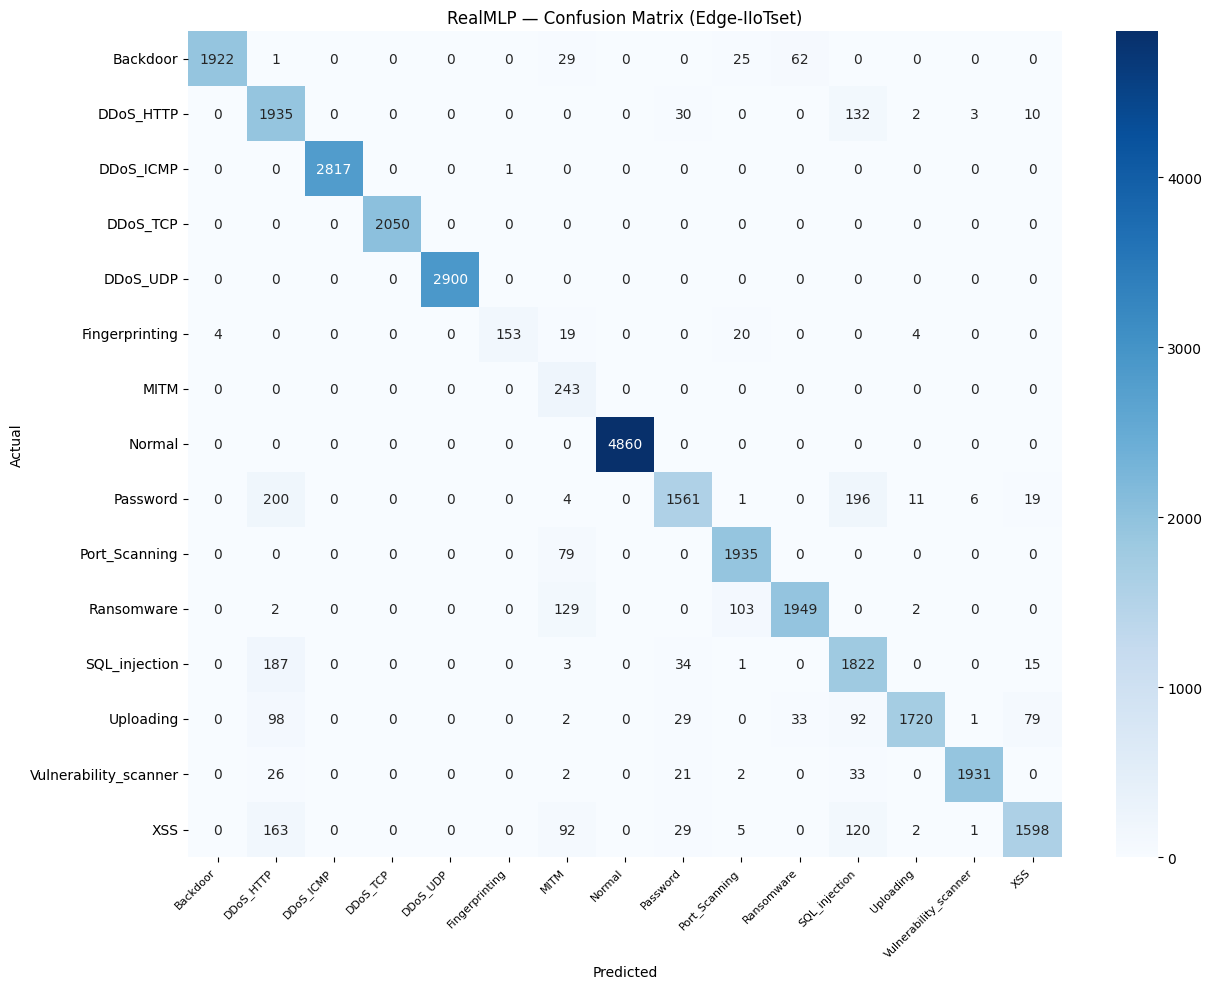

Saved: /content/drive/MyDrive/edge_iiotset_ml_outputs/realmlp_confusion_matrix.png


In [23]:

# CELL 8 — RealMLP TEST EVALUATION

realmlp_preds = realmlp_model.predict(X_test_s)

realmlp_results = evaluate(
    "RealMLP", y_test, realmlp_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

In [24]:

# CELL 9 — TabM
from tabm import TabM

X_tr = torch.tensor(X_train_s, dtype=torch.float32)
X_v  = torch.tensor(X_val_s,   dtype=torch.float32)
X_te = torch.tensor(X_test_s,  dtype=torch.float32)
y_tr = torch.tensor(y_train,   dtype=torch.long)
y_v  = torch.tensor(y_val,     dtype=torch.long)
y_te = torch.tensor(y_test,    dtype=torch.long)

train_dl = DataLoader(TensorDataset(X_tr, y_tr),
                      batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(TensorDataset(X_v,  y_v),
                      batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(TensorDataset(X_te, y_te),
                      batch_size=BATCH_SIZE, shuffle=False)

tabm_model = TabM.make(
    n_num_features=n_features,
    cat_cardinalities=[],
    d_out=num_classes,
).to(device)

optimizer = torch.optim.AdamW(
    tabm_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

print(f"TabM params  : {sum(p.numel() for p in tabm_model.parameters()):,}")
print(f"Device       : {device}")
print(f"Max epochs   : {N_EPOCHS_TABM}")
print(f"Early stop   : {EARLY_STOPPING} epochs patience")
print("Training TabM on Edge-IIoTset...")

best_val_f1      = 0
best_state       = None
tabm_history     = []
no_improve_count = 0

for epoch in range(1, N_EPOCHS_TABM + 1):
    # Train
    tabm_model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(tabm_model(xb).mean(dim=1), yb)
        loss.backward()
        optimizer.step()

    # Validate
    tabm_model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            p = tabm_model(xb.to(device)).mean(dim=1)\
                          .argmax(dim=-1).cpu().numpy()
            preds_all.extend(p)
            true_all.extend(yb.numpy())

    val_f1  = f1_score(true_all, preds_all, average="macro", zero_division=0)
    val_acc = accuracy_score(true_all, preds_all)
    tabm_history.append({"epoch": epoch,
                         "val_f1": val_f1, "val_acc": val_acc})

    print(f"  Epoch {epoch:03d}/{N_EPOCHS_TABM} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"No improve: {no_improve_count}/{EARLY_STOPPING}")

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_state       = {k: v.cpu()
                            for k, v in tabm_model.state_dict().items()}
        no_improve_count = 0
        print(f"   New best F1: {best_val_f1:.4f} — model saved")
    else:
        no_improve_count += 1
        if no_improve_count >= EARLY_STOPPING:
            print(f"\n Early stopping at epoch {epoch} "
                  f"— no improvement for {EARLY_STOPPING} epochs")
            break

print(f"\nBest Val F1 (TabM): {best_val_f1:.4f} ")

TabM params  : 924,992
Device       : cuda
Max epochs   : 256
Early stop   : 20 epochs patience
Training TabM on Edge-IIoTset...
  Epoch 001/256 | Val Acc: 0.7090 | Val F1: 0.6241 | No improve: 0/20
   New best F1: 0.6241 — model saved
  Epoch 002/256 | Val Acc: 0.7679 | Val F1: 0.7161 | No improve: 0/20
   New best F1: 0.7161 — model saved
  Epoch 003/256 | Val Acc: 0.7789 | Val F1: 0.7180 | No improve: 0/20
   New best F1: 0.7180 — model saved
  Epoch 004/256 | Val Acc: 0.7853 | Val F1: 0.7341 | No improve: 0/20
   New best F1: 0.7341 — model saved
  Epoch 005/256 | Val Acc: 0.7907 | Val F1: 0.7439 | No improve: 0/20
   New best F1: 0.7439 — model saved
  Epoch 006/256 | Val Acc: 0.8056 | Val F1: 0.7497 | No improve: 0/20
   New best F1: 0.7497 — model saved
  Epoch 007/256 | Val Acc: 0.8086 | Val F1: 0.7672 | No improve: 0/20
   New best F1: 0.7672 — model saved
  Epoch 008/256 | Val Acc: 0.8032 | Val F1: 0.7581 | No improve: 0/20
  Epoch 009/256 | Val Acc: 0.8094 | Val F1: 0.7500 |


  TabM — Results
  Accuracy      : 0.8344
  F1 (macro)    : 0.7933
  F1 (weighted) : 0.8360

                       precision    recall  f1-score   support

             Backdoor       0.98      0.94      0.96      2039
            DDoS_HTTP       0.66      0.73      0.70      2112
            DDoS_ICMP       1.00      1.00      1.00      2818
             DDoS_TCP       0.95      0.87      0.91      2050
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.91      0.69      0.79       200
                 MITM       0.40      1.00      0.57       243
               Normal       1.00      1.00      1.00      4860
             Password       0.42      0.44      0.43      1998
        Port_Scanning       0.86      0.96      0.91      2014
           Ransomware       0.93      0.89      0.91      2185
        SQL_injection       0.57      0.67      0.62      2062
            Uploading       0.89      0.48      0.62      2054
Vulnerability_scanner  

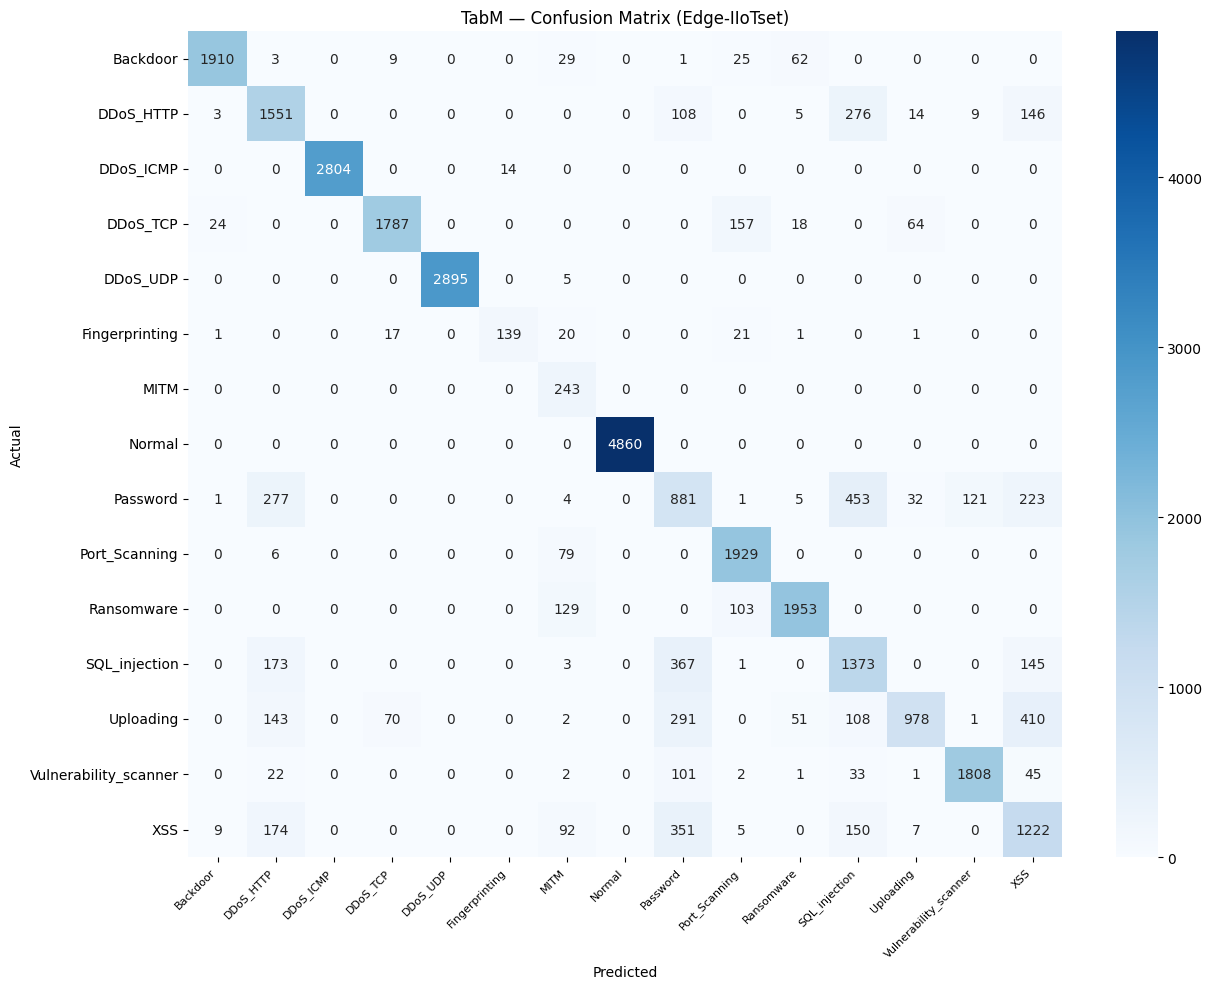

Saved: /content/drive/MyDrive/edge_iiotset_ml_outputs/tabm_confusion_matrix.png


In [25]:

# CELL 10 — TabM TEST EVALUATION

tabm_model.load_state_dict(
    {k: v.to(device) for k, v in best_state.items()})
tabm_model.eval()

preds_all, true_all = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        p = tabm_model(xb.to(device)).mean(dim=1)\
                      .argmax(dim=-1).cpu().numpy()
        preds_all.extend(p)
        true_all.extend(yb.numpy())

tabm_results = evaluate(
    "TabM", true_all, preds_all,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)


========== FINAL COMPARISON — Edge-IIoTset ==========
         accuracy  f1_macro  f1_weighted
model                                   
RealMLP    0.9314    0.8995       0.9341
TabM       0.8344    0.7933       0.8360

Saved: /content/drive/MyDrive/edge_iiotset_ml_outputs/edge_iiotset_realmlp_tabm_results.csv


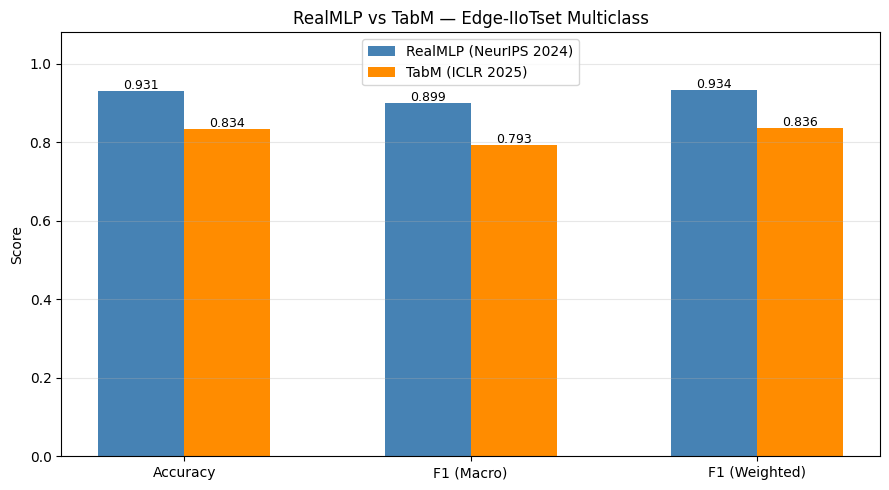

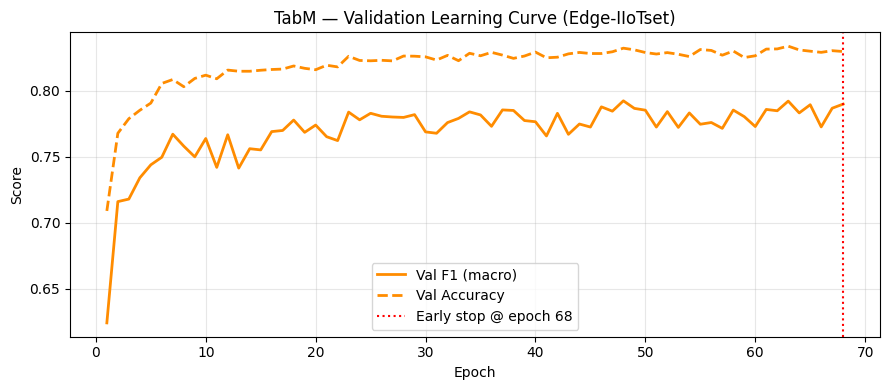


 All outputs saved to Drive:
  → /content/drive/MyDrive/edge_iiotset_ml_outputs/edge_iiotset_realmlp_tabm_results.csv
  → /content/drive/MyDrive/edge_iiotset_ml_outputs/edge_iiotset_comparison.png
  → /content/drive/MyDrive/edge_iiotset_ml_outputs/edge_iiotset_tabm_curve.png
  → realmlp_confusion_matrix.png
  → tabm_confusion_matrix.png


In [27]:

# CELL 11 — FINAL COMPARISON + SAVE

results_df = pd.DataFrame([realmlp_results, tabm_results]).set_index("model")

print("\n========== FINAL COMPARISON — Edge-IIoTset ==========")
print(results_df.round(4).to_string())

# Save CSV
csv_path = os.path.join(
    DRIVE_OUT_DIR, "edge_iiotset_realmlp_tabm_results.csv")
results_df.to_csv(csv_path)
print(f"\nSaved: {csv_path}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
metrics      = ["accuracy", "f1_macro", "f1_weighted"]
metric_names = ["Accuracy", "F1 (Macro)", "F1 (Weighted)"]
x     = np.arange(len(metrics))
width = 0.3

bars1 = ax.bar(x - width/2,
               [realmlp_results[m] for m in metrics],
               width, label="RealMLP (NeurIPS 2024)", color="steelblue")
bars2 = ax.bar(x + width/2,
               [tabm_results[m]    for m in metrics],
               width, label="TabM (ICLR 2025)",       color="darkorange")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("RealMLP vs TabM — Edge-IIoTset Multiclass")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
bar_path = os.path.join(DRIVE_OUT_DIR, "edge_iiotset_comparison.png")
plt.savefig(bar_path, dpi=150); plt.show()

# TabM learning curve
fig, ax = plt.subplots(figsize=(9, 4))
epochs = [h["epoch"]   for h in tabm_history]
f1s    = [h["val_f1"]  for h in tabm_history]
accs   = [h["val_acc"] for h in tabm_history]
ax.plot(epochs, f1s,  label="Val F1 (macro)",
        color="darkorange", linewidth=2)
ax.plot(epochs, accs, label="Val Accuracy",
        color="darkorange", linewidth=2, linestyle="--")
ax.axvline(x=len(tabm_history), color="red", linestyle=":",
           label=f"Early stop @ epoch {len(tabm_history)}")
ax.set_title("TabM — Validation Learning Curve (Edge-IIoTset)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
curve_path = os.path.join(DRIVE_OUT_DIR, "edge_iiotset_tabm_curve.png")
plt.savefig(curve_path, dpi=150); plt.show()

print("\n All outputs saved to Drive:")
print(f"   {csv_path}")
print(f"   {bar_path}")
print(f"   {curve_path}")
print(f"   realmlp_confusion_matrix.png")
print(f"   tabm_confusion_matrix.png")